In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first

# from kret_lgbm._core.lgbm_nb_imports import *
# from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *

# from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *

# from kret_sklearn._core.sklearn_nb_imports import *
# from kret_torch_utils._core.torch_nb_imports import *
# from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 3.1598 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0006 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_type_hints._core.types_nb_imports] Imported kret_type_hints._core.types_nb_imports in 0.0010 seconds
[kret_utils._core.utils_nb_imports] Imported kret_utils._core.utils_nb_imports in 0.0071 seconds


In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.datasets.memo_cdnnba_pl import CDNNBAMemoPL
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation

memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 74 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

Calculating bin_sr(15,)
Calculating bin_sr(30,)
Calculating bin_sr(60,)


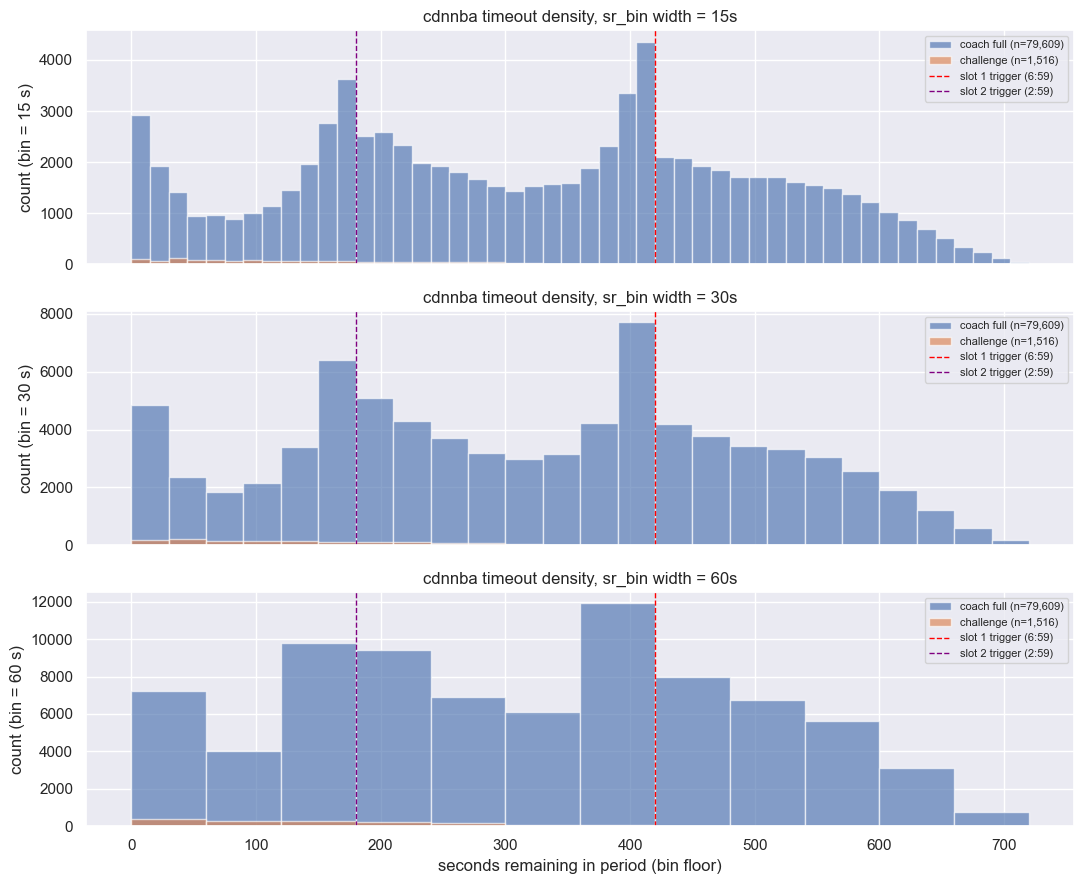

In [5]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

df = pl.DataFrame._from_pydf(memo_cdn.cdnnba._df)
df = df.filter((pl.col("actionType") == "timeout") & pl.col("period").is_in([1, 2, 3, 4]))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, width in zip(axes, [15, 30, 60]):
    binned = df.with_columns(memo_cdn.bin_sr(width).gather(df["orderNumber"] - df["orderNumber"]))  # dummy alignment
    # simpler: just compute bins directly here
    bins = (df["seconds_remaining"] // width * width).cast(pl.Int32)
    df2 = df.with_columns(bins.alias("sr_bin"))
    for sub, color, label in [("full", "C0", "coach full"), ("challenge", "C1", "challenge")]:
        vals = df2.filter(pl.col("subType") == sub)["sr_bin"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(
            vals, bins=np.arange(0, 720 + width, width), alpha=0.65, label=f"{label} (n={len(vals):,})", color=color
        )
    ax.axvline(420, color="red", linestyle="--", linewidth=1, label="slot 1 trigger (6:59)")
    ax.axvline(180, color="purple", linestyle="--", linewidth=1, label="slot 2 trigger (2:59)")
    ax.set_ylabel(f"count (bin = {width} s)")
    ax.set_title(f"cdnnba timeout density, sr_bin width = {width}s")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds remaining in period (bin floor)")
plt.tight_layout()
plt.show()

# Part 3 - cdnnba classification 

Examine the cdnnba data and predictions


## Plots

In [6]:
seasons = None  # (2020, 2025)
cdn_pl = TVTimeoutValidation._prep_cdnnba(memo_cdn, seasons=seasons)
classified = TVTimeoutValidation.classify_timeouts(cdn_pl, source="cdnnba", seasons=seasons)

Calculating timeout_duration_s


In [7]:
# Validation
r = TVTimeoutValidation.validate_against_cdnnba(memo_cdn, seasons=seasons)
print(r.summary())  # F1=1.000 (predicting from the same signal we score on)

# Confusion matrix
TVTimeoutValidation.confusion_matrix_cdnnba(memo_cdn, seasons=seasons)

cdnnba reclassification: n_gt=56,895 n_pred=56,895 TP=56,895 FP=0 FN=0 | P=1.000 R=1.000 F1=1.000


predicted_role,challenge,discretionary,slot_1_mandatory,slot_2_mandatory,TOTAL
gt,,,,,
mandatory,0,0,48530,8365,56895
not_mandatory,1555,23747,0,0,25302
TOTAL,1555,23747,48530,8365,82197


In [8]:
figs = TimeoutInjectionPlots.diagnose_cdnnba(classified, full_pbp_pl=memo_cdn)

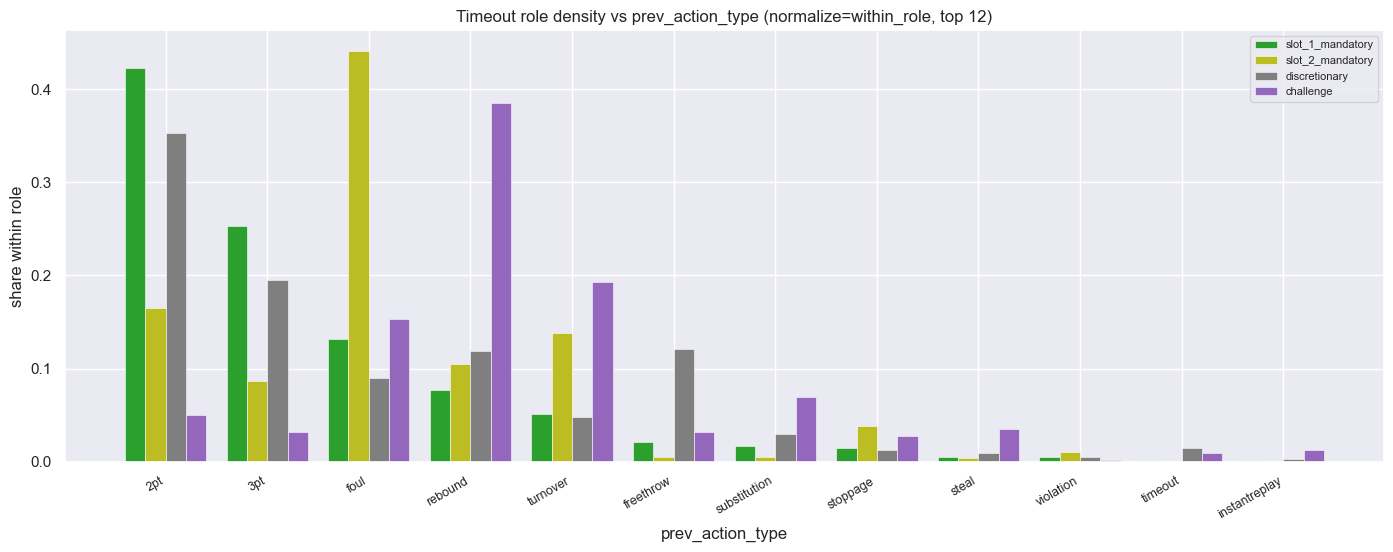

In [9]:
figs["role_vs_prev_action_type"]

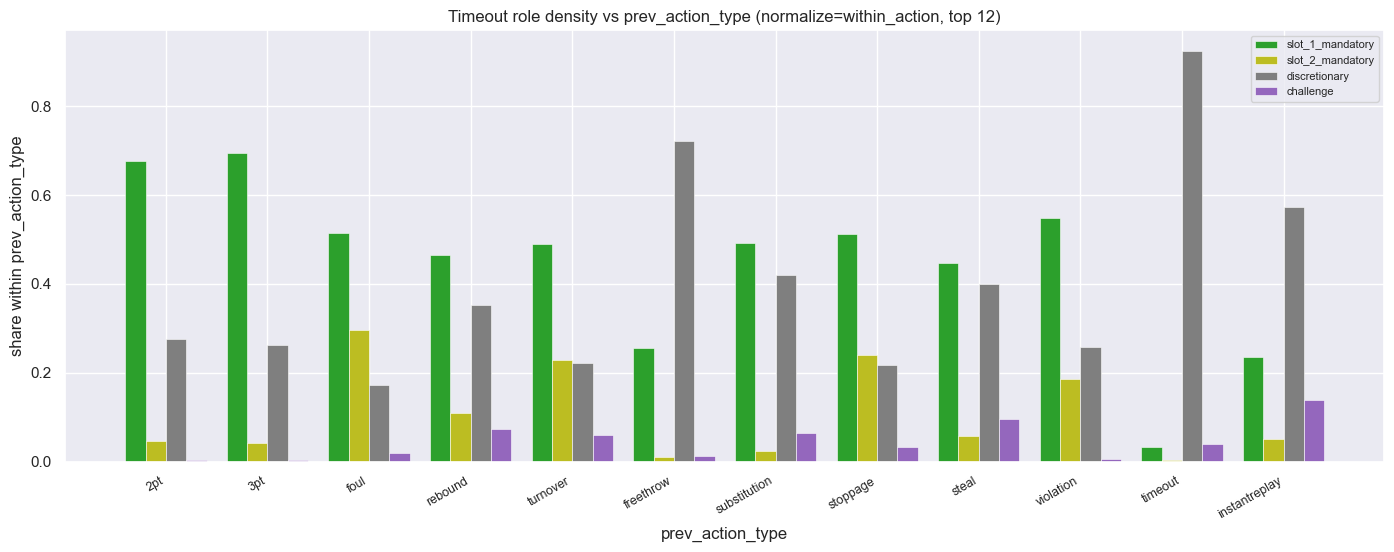

In [10]:
fig, ax, mat = TimeoutInjectionPlots.plot_role_vs_prev_action_type(
    classified, memo_cdn, normalize="within_action"  # "given X happened, what fraction of TOs are mandatory?"
)
fig

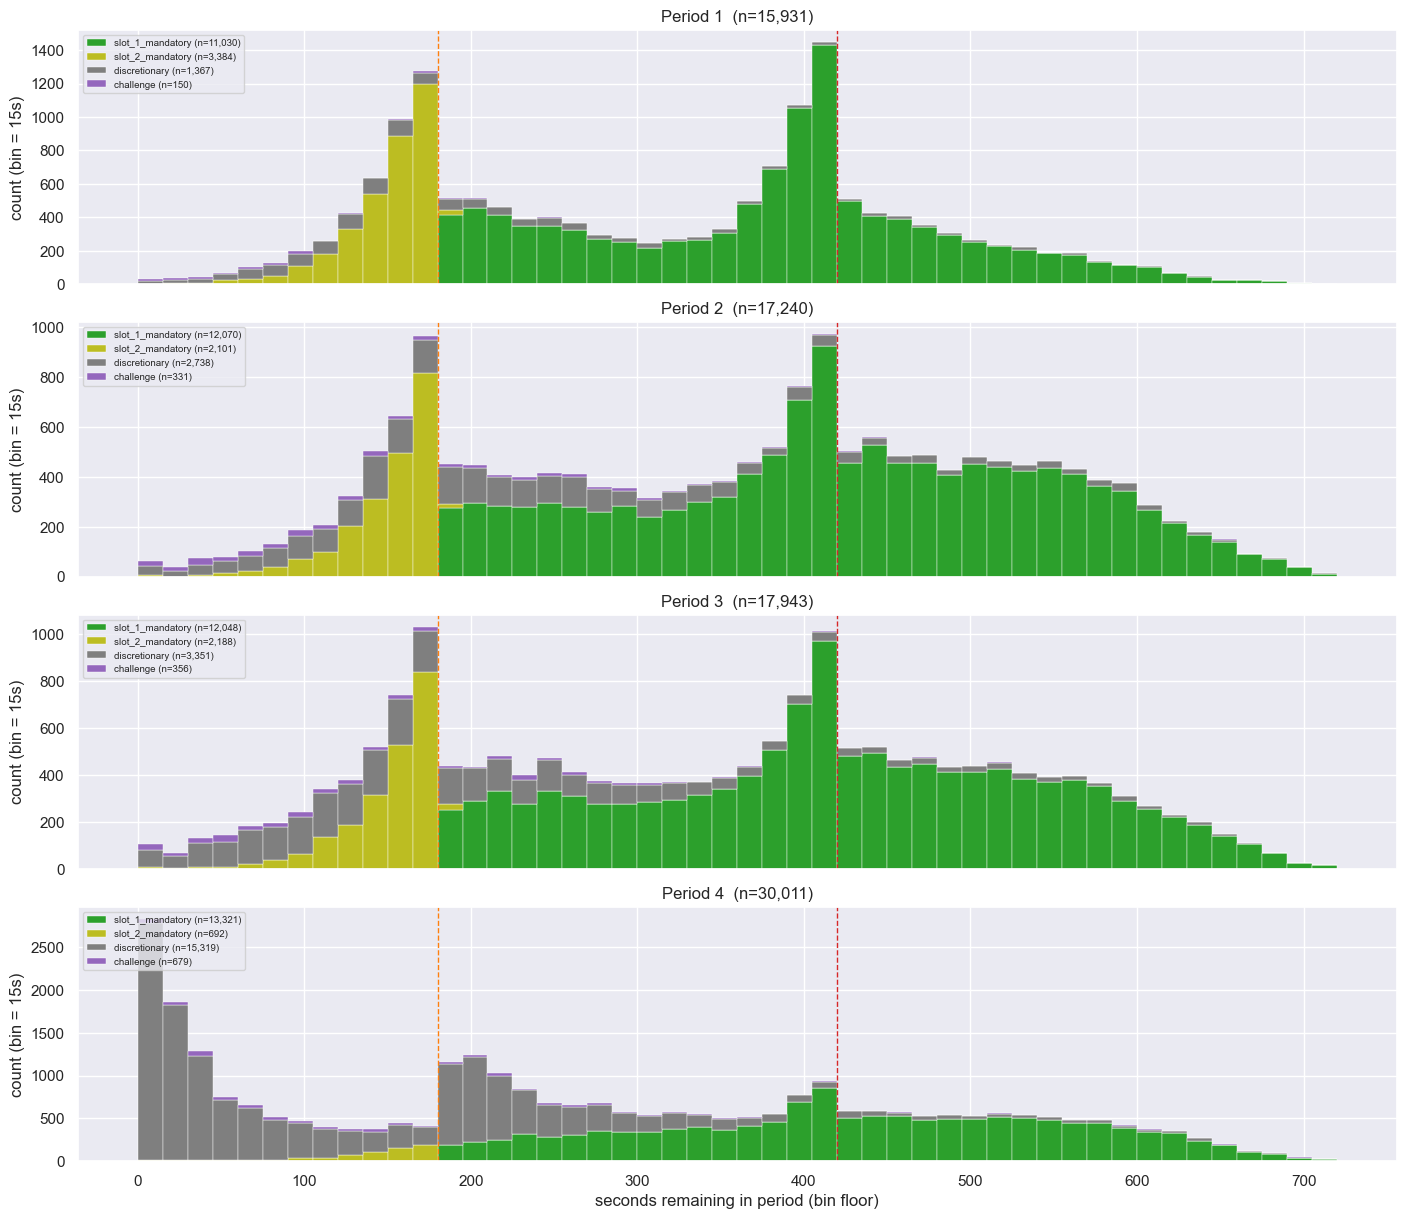

In [11]:
figs["role_vs_sr"]

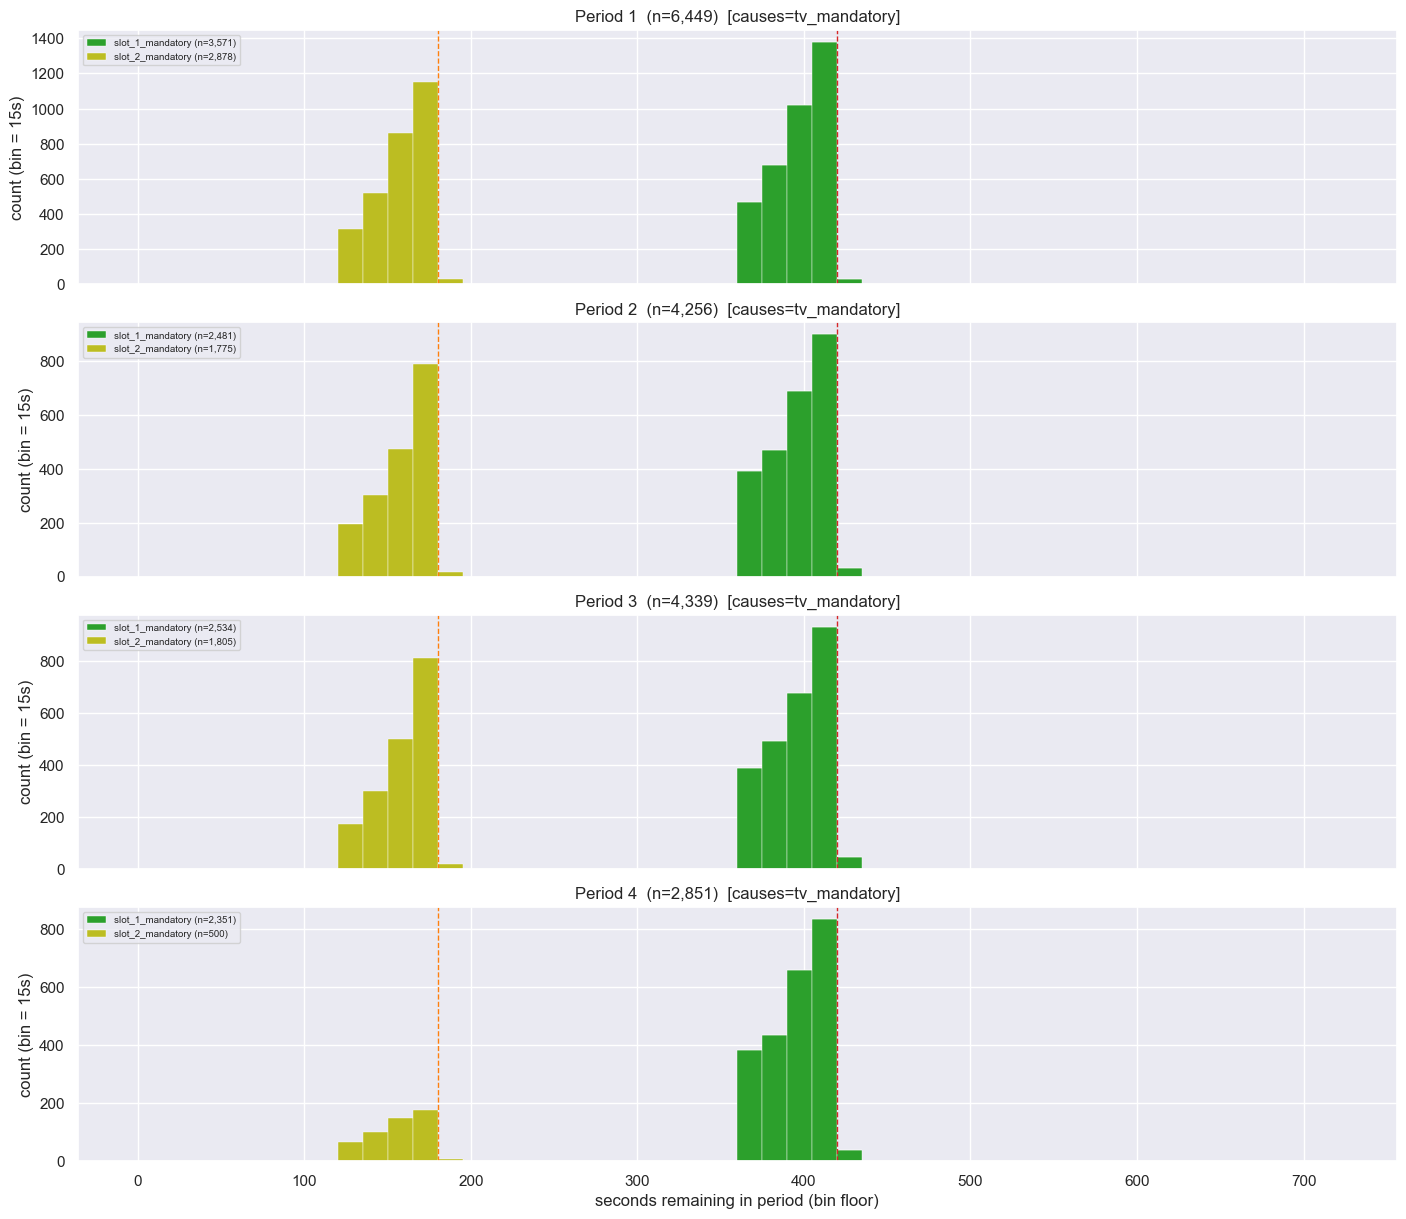

In [12]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",))
fig

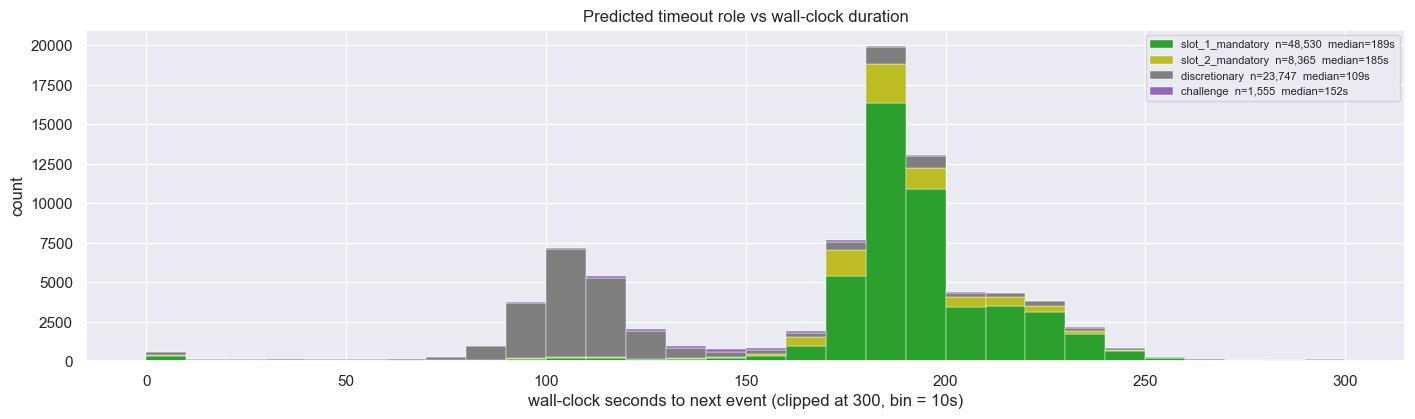

In [13]:
figs["role_vs_duration"]

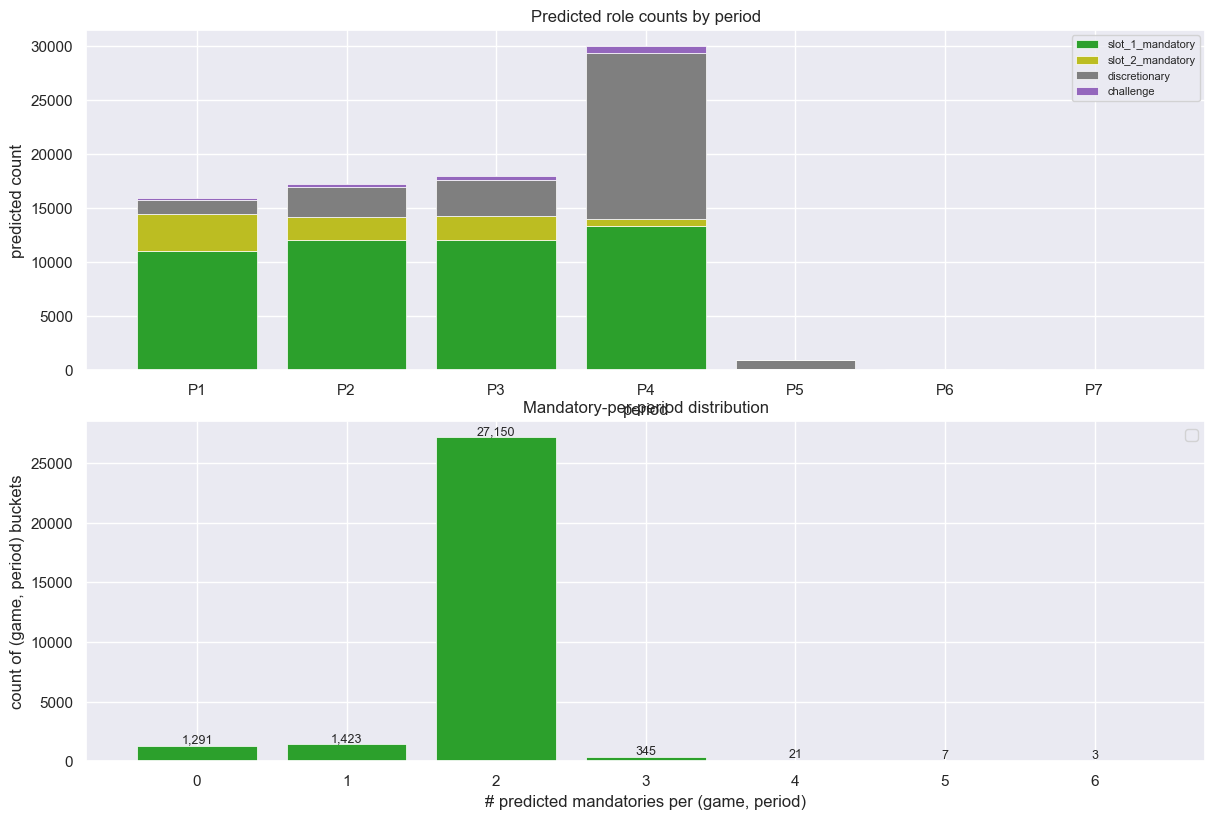

In [14]:
figs["role_counts_per_period"]

In [15]:
# figs["team_mandatory_share"]

# Sandbox

In [16]:
index = [1300906, 543597]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [17]:
# help(UKS_NP_PD.get_nearby_rows) / UKS_NP_PD.get_nearby_rows?

In [18]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(39)

In [19]:
UKS_NP_PD.dtt(
    [
        # memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    # filter=f_nearby,
    # highlight_filter=f_index,
    n=10,
)

Calculating f_timeout


,gameId,orderNumber,period,actionType,subType,seconds_remaining,season,season_type,personId,teamId,teamTricode,qualifiers,timeActual,timeout_duration_s,timeout_role,timeout_cause
,int64,int64,int64,str,str,float64,int64,str,int64,float64,category,str,"datetime64[us, UTC]",float64,str,str
1951317,22201183,6710000,4,turnover,out-of-bounds,19.500,2022,rg,201599,1610612743.000,DEN,NaN,2023-04-05 02:16:18.100000+00:00,NaN,,
2041364,22300115,6310000,4,foul,personal,115.000,2023,rg,1641739,1610612757.000,POR,"inpenalty, 2freethrow",2023-11-02 01:12:21.500000+00:00,NaN,,
2167767,22300341,3520000,3,turnover,bad pass,692.000,2023,rg,1631101,1610612757.000,POR,NaN,2023-12-17 03:31:23+00:00,NaN,,
2410415,22300784,1450000,1,rebound,defensive,133.000,2023,rg,1630530,1610612740.000,NOP,NaN,2024-02-15 01:29:50.600000+00:00,NaN,,
2600080,22301135,4900000,4,rebound,defensive,684.000,2023,rg,1631096,1610612760.000,OKC,NaN,2024-04-07 23:45:53.500000+00:00,NaN,,
2775925,22400220,530000,1,3pt,Jump Shot,436.000,2024,rg,1627824,1610612755.000,PHI,NaN,2024-11-14 00:46:38.800000+00:00,NaN,,
2943133,22400520,7820000,4,rebound,defensive,6.600,2024,rg,1630217,1610612763.000,MEM,NaN,2025-01-10 03:37:18.400000+00:00,NaN,,
3058946,22400728,4440000,3,2pt,Layup,6.100,2024,rg,1641765,1610612742.000,DAL,pointsinthepaint,2025-02-07 02:14:16.900000+00:00,NaN,,
3735851,22500685,5110000,4,rebound,defensive,686.000,2025,rg,1631221,1610612756.000,PHX,NaN,2026-01-30 03:57:46.200000+00:00,NaN,,


In [20]:
UKS_NP_PD.dtt([classified["timeout_role"].value_counts(), classified["timeout_cause"].value_counts()], n=-1)

,timeout_role,count
,str,uint32
0,discretionary,23747
1,slot_2_mandatory,8365
2,challenge,1555
3,slot_1_mandatory,48530
4,,4086589
,timeout_cause,count
,str,uint32
0,tv_mandatory,17896
1,challenge,1555


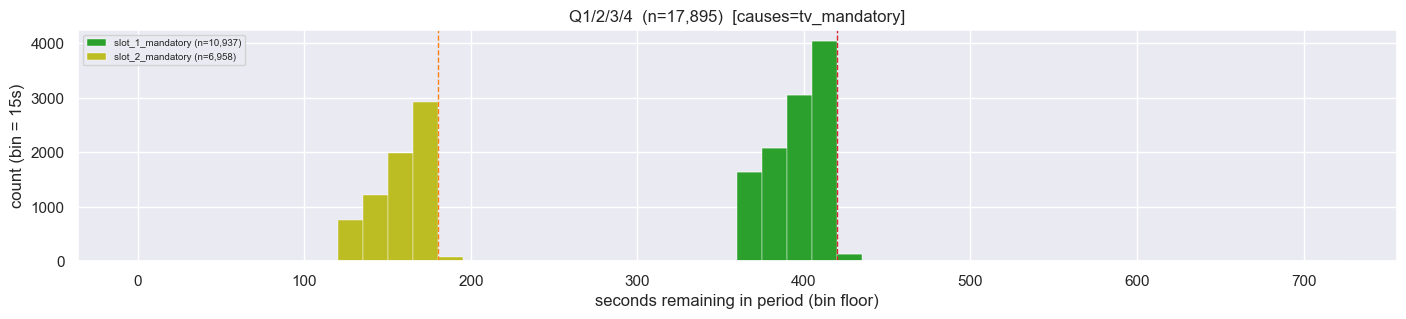

In [21]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",), combine_periods=True)
fig

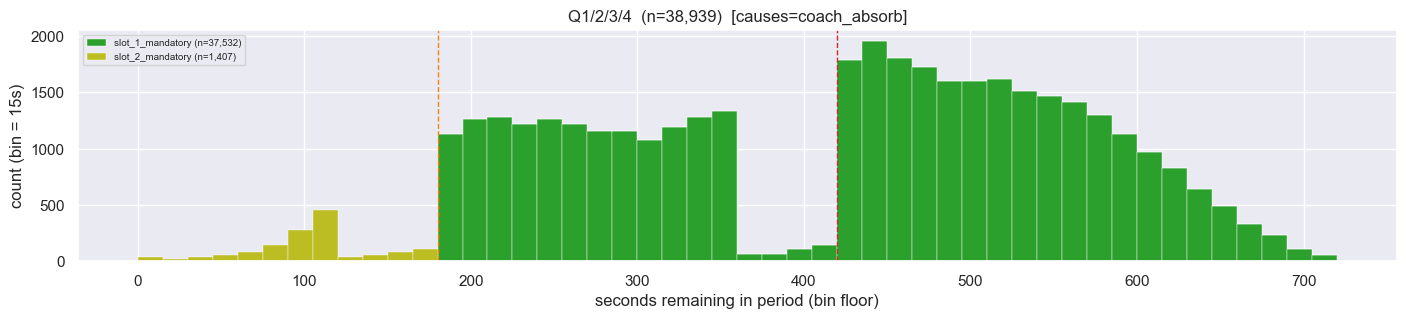

In [22]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_absorb",), combine_periods=True)
fig

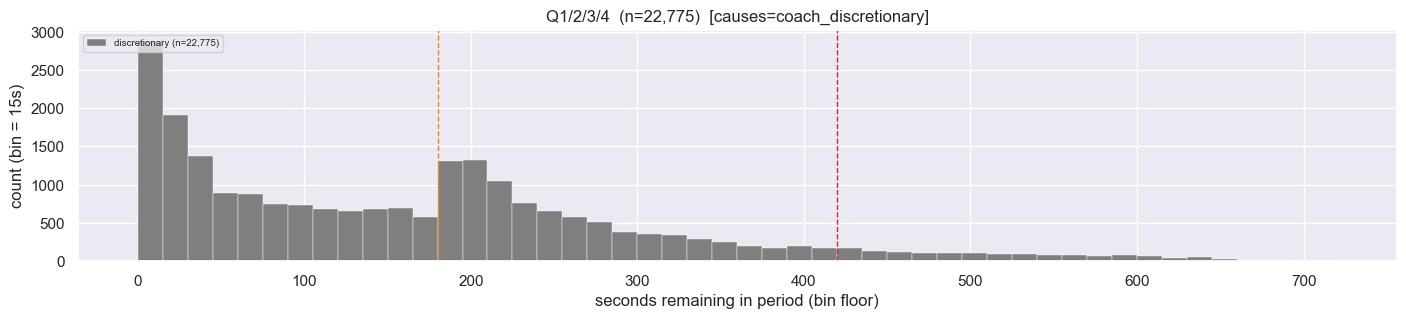

In [23]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_discretionary",), combine_periods=True)
fig